## Food image classisifier

In notebook, we'll build a food image classifier in ***PyTorch***. This classifier will then be used in the ***ExplainableML*** to show how the ***LIME*** image explainer can be used to visualize what the model is paying the most attention to in order to assign the class label. But before we dive into building the classifier, we have to data wrangling to do.

### The dataset

The data used for this project was taken from the Hugging Face hub at:  
https://huggingface.co/datasets/ewanlong/Food_Classification_Dataset/blob/main/Food_Classification_Dataset.zip

The model card describes the data as follows:

+ Dataset Name: 'Food Image Classification Dataset'
+ Dataset Size: 24K unique images
+ Dataset Description: 35 varieties of both Indian and Western appetizers
+ Dataset Source: The unique images obtained from various Google resources by Kaggle user Harish Kumar
+ Dataset License: CC0: Public Domain
+ Dataset Quality:
  - Meticulously curated images ensuring diversity and representativeness
  - Provides a solid foundation for developing robust and precise image classification algorithms
  - Encourages exploration in the fascinating field of food image classification
+ Expected Update Frequency: Quarterly

The data was downloaded so that processing could be done locally. The first thing one notices is that the images are different sizes. Because we will be building a (convolutional) neural network (CNN) classifier, our model will be expecting inputs that are the same size. One practical way to handle this constraint is to resize the images to a pre-determined size. This requires us to decide on the size we should normalize our images to.

### Image size selection

Picking our image size requires us to balance two opposing objectives:

+ The smaller our chosen size, the more data that is lost from the larger images.
+ The larger our chosen size, the more distortion we inject into the smaller images.

One reasonable appoach would be to select the mean image size. We'll need to iterate through the images and save their sizes.

### Classification target

We'll work on a binary classification model which will use a subset of these images. The two target classes will be ***desert*** and ***not desert***. For the ***desert*** target class, we'll gather the following images: **apple_pie**, **cheesecake**, **Donut** and **ice_cream**. For the ***not desert*** target class, we'll gather the following images: **Crispy Chicken**, **Hot Dog** and **Sandwich**. There are 4500 images in the desert (positive) class and 4548 images in the ***not desert*** class, so they are well-balanced.


In [1]:

# set the target folders
desert_dirs = ["apple_pie", "cheesecake", "Donut", "ice_cream"]  # 4500 images
desert_dirs_paths = []
desert_image_files = []
desert_image_widths = []
desert_image_heights = []
desert_image_target = []
desert_original_class = []

not_desert_dirs = ["Crispy Chicken", "Hot Dog", "Sandwich"]  # 4548 images
not_desert_dirs_paths = []
not_desert_image_files = []
not_desert_image_widths = []
not_desert_image_heights = []
not_desert_image_target = []
not_desert_original_class = []

In [2]:
from pathlib import Path
# read through the image files and collect their sizes
img_dir = "C:/data/Food_Classification_Dataset"

dir_path = Path(img_dir)
# collect the subset of images used for this analysis
for file_path in dir_path.iterdir():
    if file_path.is_dir and file_path.parts[-1] in desert_dirs:
        # print(f"adding {file_path} to deserts dir paths")
        desert_dirs_paths.append(file_path)
    if file_path.is_dir and file_path.parts[-1] in not_desert_dirs:
        # print(f"adding {file_path} to NOT deserts dir paths")
        not_desert_dirs_paths.append(file_path)

In [3]:
from PIL import Image
import pandas as pd
# iterate through each image folder and gather the size of each image
# start with positive class image stats
for i, im_path in enumerate(desert_dirs_paths):
    # get sizes of each image
    desert_subdir = Path(im_path)
    print(f"*** working on dir: {desert_subdir} ***")
    for desert_img_path in desert_subdir.iterdir():
        desert_image_files.append(desert_img_path)
        img = Image.open(desert_img_path)
        desert_image_widths.append(img.size[0])
        desert_image_heights.append(img.size[1])
        desert_image_target.append(1)
        desert_original_class.append(desert_dirs[i])
        # print(f"path: {desert_img_path} | Original size: {img.size[0], img.size[1]}")
# load the negative class image stats
for i, im_path in enumerate(not_desert_dirs_paths):
    # get sizes of each image
    not_desert_subdir = Path(im_path)
    print(f"*** working on dir: {not_desert_subdir} ***")
    for not_desert_img_path in not_desert_subdir.iterdir():
        not_desert_image_files.append(desert_img_path)
        img = Image.open(not_desert_img_path)
        not_desert_image_widths.append(img.size[0])
        not_desert_image_heights.append(img.size[1])
        not_desert_image_target.append(0)
        not_desert_original_class.append(not_desert_dirs[i])
        # print(f"path: {not_desert_img_path} | Original size: {img.size[0], img.size[1]}")

# create consolidated dataframe and export
all_paths = desert_image_files
all_paths.extend(not_desert_image_files)
original_class = desert_original_class
original_class.extend(not_desert_original_class)
target = desert_image_target
target.extend(not_desert_image_target)
widths = desert_image_widths
widths.extend(not_desert_image_widths)
heights = desert_image_heights
heights.extend(not_desert_image_heights)

# print(f"length: {len(height)} | first: {height[0]}")

df_images = pd.DataFrame({"path": all_paths,
                          "original_class": original_class,
                          "target": target,
                          "width": widths,
                          "height": heights})
# print(df_images.head(5))
# print(df_images.tail(5))

*** working on dir: C:\data\Food_Classification_Dataset\apple_pie ***
*** working on dir: C:\data\Food_Classification_Dataset\cheesecake ***
*** working on dir: C:\data\Food_Classification_Dataset\Donut ***
*** working on dir: C:\data\Food_Classification_Dataset\ice_cream ***
*** working on dir: C:\data\Food_Classification_Dataset\Crispy Chicken ***
*** working on dir: C:\data\Food_Classification_Dataset\Hot Dog ***
*** working on dir: C:\data\Food_Classification_Dataset\Sandwich ***


## Visualize the class distributions

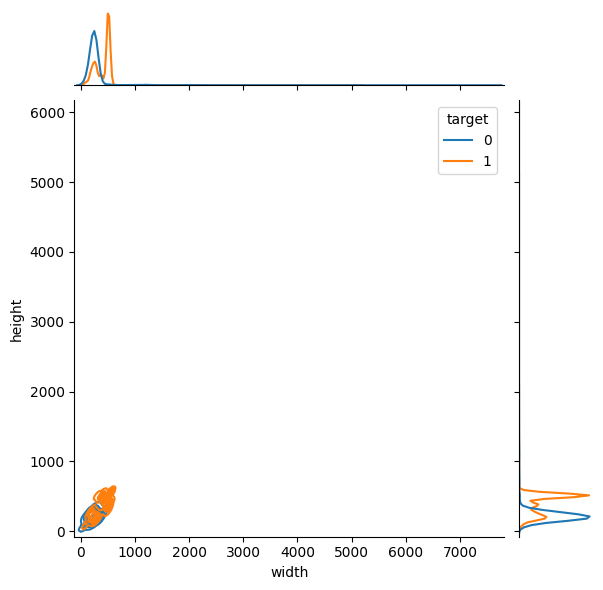

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.jointplot(
    data=df_images,
    x="width", y="height",
    hue="target", kind="kde"
)

plt.show()  # looks like we have some large outlier images

## Drop the large outlier images

We'll only do this to improve the visualization. We'll keep those larger images and resize them with the rest of the data.

In [5]:
thresh = 700
df_images_trimmed = df_images.loc[(df_images["width"] <= thresh) & (df_images["height"] <= thresh), :]
df_images_trimmed.shape  # (8917, 5) so we only lost 9048 - 8917 = 131 images
print(f"Filtered out {df_images.shape[0] - df_images_trimmed.shape[0]} images at threshold of {thresh} or above")

Filtered out 174 images at threshold of 700 or above


Mean class 0 size: (240.95, 210.2)
Mean class 1 size: (409.18, 387.52)
Overall Mean size: (325.25, 299.06)


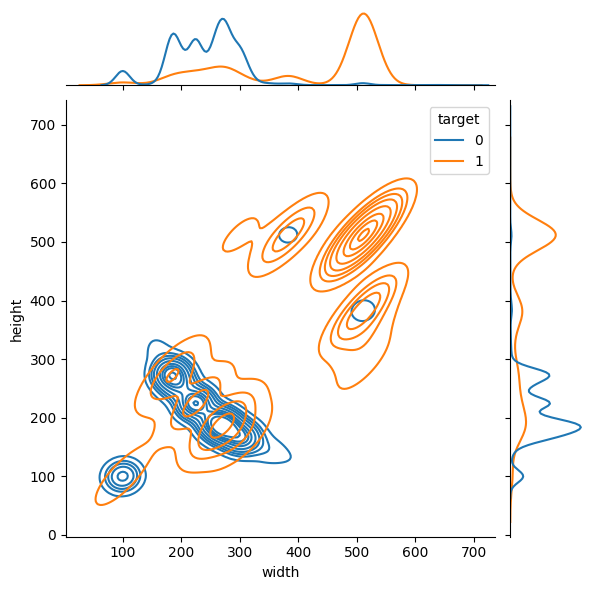

In [6]:
sns.jointplot(
    data=df_images_trimmed,
    x="width", y="height",
    hue="target", kind="kde"
)

# compute means with the outlier removed
mean_class_0_width = df_images_trimmed.loc[df_images_trimmed["target"] == 0, ["width"]].mean()["width"]
mean_class_0_height = df_images_trimmed.loc[df_images_trimmed["target"] == 0, ["height"]].mean()["height"]
mean_class_1_width = df_images_trimmed.loc[df_images_trimmed["target"] == 1, ["width"]].mean()["width"]
mean_class_1_height = df_images_trimmed.loc[df_images_trimmed["target"] == 1, ["height"]].mean()["height"]
mean_width = df_images_trimmed.loc[:, ["width"]].mean()["width"]
mean_height = df_images_trimmed.loc[:, ["height"]].mean()["height"]

# print(type(mean_class_0_width))
print(f"Mean class 0 size: {(round(mean_class_0_width.item(), 2), round(mean_class_0_height.item(), 2))}")
print(f"Mean class 1 size: {(round(mean_class_1_width.item(), 2), round(mean_class_1_height.item(), 2))}")
print(f"Overall Mean size: {(round(mean_width.item(), 2), round(mean_height.item(), 2))}")

plt.show()

## Comparing the target distributions

Looks like the positive class (desert) images tend to be both wider an higher than the negative class images (not desert).

## Overall mean

We'll resize all our images to **(325, 300)**.

In [7]:
# import torch.nn as nn
# import torch.optim as optim

# class Net(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.feature_extractor = nn.Sequential(
#             nn.conv2d(),
#             nn.ELU(),
#             nn.MaxPool2d(kernel_size=2),
#             nn.Conv2d()
#         )